In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("coffee_sales.csv")
df.head()

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country,Size,Unit Price,Sales,Coffee Type Name,Roast Type Name,Loyalty Card,City,Postcode,Country_cust,Email_cust,Loyalty Card_cust,Phone Number,Coffee Type,Size_prod,Unit Price_prod,Profit
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,United States,1.0,9.95,19.90,Robusta,Medium,Yes,Paterson,7505,United States,aallner0@lulu.com,Yes,+1 (862) 817-0124,Rob,1.0,9.95,0.5970
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,United States,0.5,8.25,41.25,Excelsa,Medium,Yes,Paterson,7505,United States,aallner0@lulu.com,Yes,+1 (862) 817-0124,Exc,0.5,8.25,0.9075
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,United States,1.0,12.95,12.95,Arabica,Large,Yes,San Antonio,78205,United States,jredholes2@tmall.com,Yes,+1 (210) 986-6806,Ara,1.0,12.95,1.1655
3,IPP-31994-879,2022-01-21,65223-29612-CB,E-D-0.5,3,Shaylynn Lobe,slobe6@nifty.com,United States,0.5,7.29,21.87,Excelsa,Dark,Yes,Dayton,45440,United States,slobe6@nifty.com,Yes,+1 (937) 954-4541,Exc,0.5,7.29,0.8019
4,EZT-46571-659,2019-01-02,03396-68805-ZC,R-M-0.5,3,Guthrey Petracci,gpetracci8@livejournal.com,United States,0.5,5.97,17.91,Robusta,Medium,No,Los Angeles,90045,United States,gpetracci8@livejournal.com,No,+1 (310) 868-1842,Rob,0.5,5.97,0.3582


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 794 entries, 0 to 793
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order ID           794 non-null    str    
 1   Order Date         794 non-null    str    
 2   Customer ID        794 non-null    str    
 3   Product ID         794 non-null    str    
 4   Quantity           794 non-null    int64  
 5   Customer Name      794 non-null    str    
 6   Email              794 non-null    str    
 7   Country            794 non-null    str    
 8   Size               794 non-null    float64
 9   Unit Price         794 non-null    float64
 10  Sales              794 non-null    float64
 11  Coffee Type Name   794 non-null    str    
 12  Roast Type Name    794 non-null    str    
 13  Loyalty Card       794 non-null    str    
 14  City               794 non-null    str    
 15  Postcode           794 non-null    str    
 16  Country_cust       794 non-null    st

In [5]:
missing_check = df.isnull().sum()
print("Missing Values:\n", missing_check)

Missing Values:
 Order ID               0
Order Date             0
Customer ID            0
Product ID             0
Quantity               0
Customer Name          0
Email                  0
Country                0
Size                   0
Unit Price             0
Sales                  0
Coffee Type Name       0
Roast Type Name        0
Loyalty Card           0
City                   0
Postcode               0
Country_cust           0
Email_cust             0
Loyalty Card_cust      0
Phone Number         111
Coffee Type            0
Size_prod              0
Unit Price_prod        0
Profit                 0
dtype: int64


In [6]:
df_clean = df.copy()
df_clean['Phone Number'] = df_clean['Phone Number'].fillna('UNKNOWN')

In [7]:
missing_check = df_clean.isnull().sum()
print("Missing Values:\n", missing_check)

Missing Values:
 Order ID             0
Order Date           0
Customer ID          0
Product ID           0
Quantity             0
Customer Name        0
Email                0
Country              0
Size                 0
Unit Price           0
Sales                0
Coffee Type Name     0
Roast Type Name      0
Loyalty Card         0
City                 0
Postcode             0
Country_cust         0
Email_cust           0
Loyalty Card_cust    0
Phone Number         0
Coffee Type          0
Size_prod            0
Unit Price_prod      0
Profit               0
dtype: int64


In [8]:
duplicate_rows = df_clean[df.duplicated()]
print("Duplicate Rows:\n", duplicate_rows)

Duplicate Rows:
 Empty DataFrame
Columns: [Order ID, Order Date, Customer ID, Product ID, Quantity, Customer Name, Email, Country, Size, Unit Price, Sales, Coffee Type Name, Roast Type Name, Loyalty Card, City, Postcode, Country_cust, Email_cust, Loyalty Card_cust, Phone Number, Coffee Type, Size_prod, Unit Price_prod, Profit]
Index: []


In [9]:
drop_columns = [
    'Country_cust',
    'Email_cust',
    'Loyalty Card_cust',
    'Size_prod',
    'Unit Price_prod',
    'Coffee Type'
]
df_clean = df_clean.drop(columns=drop_columns)
df_clean.head()

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country,Size,Unit Price,Sales,Coffee Type Name,Roast Type Name,Loyalty Card,City,Postcode,Phone Number,Profit
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,United States,1.0,9.95,19.90,Robusta,Medium,Yes,Paterson,7505,+1 (862) 817-0124,0.5970
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,United States,0.5,8.25,41.25,Excelsa,Medium,Yes,Paterson,7505,+1 (862) 817-0124,0.9075
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,United States,1.0,12.95,12.95,Arabica,Large,Yes,San Antonio,78205,+1 (210) 986-6806,1.1655
3,IPP-31994-879,2022-01-21,65223-29612-CB,E-D-0.5,3,Shaylynn Lobe,slobe6@nifty.com,United States,0.5,7.29,21.87,Excelsa,Dark,Yes,Dayton,45440,+1 (937) 954-4541,0.8019
4,EZT-46571-659,2019-01-02,03396-68805-ZC,R-M-0.5,3,Guthrey Petracci,gpetracci8@livejournal.com,United States,0.5,5.97,17.91,Robusta,Medium,No,Los Angeles,90045,+1 (310) 868-1842,0.3582


In [10]:
# Mask Phone Number
def mask_phone(phone):
    if pd.isna(phone) or phone == 'UNKNOWN':
        return phone
    phone = str(phone)
    if len(phone) == 17:
        return phone[:2] + '******' + phone[-2:]
    else:
        return phone[:3] + '******' + phone[-2:]

df_clean['Phone Number Masked'] = df_clean['Phone Number'].apply(mask_phone)

# Preview masking result
df_clean[['Phone Number', 'Phone Number Masked']].sample(10)

,Phone Number,Phone Number Masked
722,+1 (619) 353-0412,+1******12
119,+353 (885) 555-9183,+35******83
629,+1 (678) 536-4251,+1******51
559,+1 (914) 524-1161,+1******61
619,+1 (214) 388-6754,+1******54
488,+1 (701) 894-8081,+1******81
621,UNKNOWN,UNKNOWN
455,+1 (213) 234-9242,+1******42
377,+1 (917) 544-7136,+1******36
320,+1 (501) 732-3644,+1******44


In [11]:
# Mask Email
def mask_email(email):
    if pd.isna(email):
        return email
    email = str(email)
    if '@' not in email:
        return '*' * len(email)
    local, domain = email.split('@', 1)
    masked_local = local[0] + '***' + local[-1] if len(local) > 2 else '***'
    return masked_local + '@' + domain

df_clean['Email Masked'] = df_clean['Email'].apply(mask_email)

# Preview masking result
df_clean[['Email', 'Email Masked']].sample(10)

,Email,Email Masked
552,dshortallj2@wikipedia.org,d***2@wikipedia.org
254,dbonhome8z@shinystat.com,d***z@shinystat.com
711,ztramelod@netlog.com,z***d@netlog.com
610,lnardonil2@hao123.com,l***2@hao123.com
352,msesonck@census.gov,m***k@census.gov
251,gtweed8v@yolasite.com,g***v@yolasite.com
252,ggoggin8x@wix.com,g***x@wix.com
395,gduckerdx@patch.com,g***x@patch.com
343,tbownecb@unicef.org,t***b@unicef.org
636,nbuneylx@jugem.jp,n***x@jugem.jp


In [12]:
# Mask Customer Name
def mask_name(name):
    if pd.isna(name):
        return name
    parts = str(name).split()
    masked_parts = [p[0] + '*' * (len(p) - 1) if len(p) > 1 else p for p in parts]
    return ' '.join(masked_parts)

df_clean['Customer Name Masked'] = df_clean['Customer Name'].apply(mask_name)

# Preview masking result
df_clean[['Customer Name', 'Customer Name Masked']].sample(10)

,Customer Name,Customer Name Masked
266,Wesley Giorgioni,W***** G********
687,Perice Eberz,P***** E****
361,Ransell McKall,R****** M*****
515,Denny O' Ronan,D**** O* R****
282,Nicko Corps,N**** C****
210,Monica Fearon,M***** F*****
586,Andie Rudram,A**** R*****
287,Casi Gwinnett,C*** G*******
358,Rodolfo Willoway,R****** W*******
393,Chantal Mersh,C****** M****


In [13]:
# Cell 12: Mask Customer City and Postcode
def mask_city(city):
    if pd.isna(city):
        return city
    city = str(city)
    if len(city) <= 2:
        return '*' * len(city)
    return city[0] + '*' * (len(city) - 2) + city[-1]

def mask_postcode(postcode):
    if pd.isna(postcode):
        return postcode
    postcode = str(postcode)
    if len(postcode) <= 2:
        return '*' * len(postcode)
    return postcode[:2] + '*' * (len(postcode) - 2)

df_clean['City Masked'] = df_clean['City'].apply(mask_city)
df_clean['Postcode Masked'] = df_clean['Postcode'].apply(mask_postcode)

# Preview masking result
df_clean[['City', 'City Masked', 'Postcode', 'Postcode Masked']].sample(10)

,City,City Masked,Postcode,Postcode Masked
431,Philadelphia,P**********a,19104,19***
161,Charlottesville,C*************e,22908,22***
310,San Bernardino,S************o,92415,92***
429,Shreveport,S********t,71115,71***
725,Seattle,S*****e,98148,98***
62,Adare,A***e,H54,H5*
260,Los Angeles,L*********s,90094,90***
98,Beaumont,B******t,D17,D1*
44,Pensacola,P*******a,32590,32***
626,Joliet,J****t,60435,60***


In [14]:
df_clean.head()

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country,Size,Unit Price,Sales,Coffee Type Name,Roast Type Name,Loyalty Card,City,Postcode,Phone Number,Profit,Phone Number Masked,Email Masked,Customer Name Masked,City Masked,Postcode Masked
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,United States,1.0,9.95,19.90,Robusta,Medium,Yes,Paterson,7505,+1 (862) 817-0124,0.5970,+1******24,a***0@lulu.com,A****** A*****,P******n,75**
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,United States,0.5,8.25,41.25,Excelsa,Medium,Yes,Paterson,7505,+1 (862) 817-0124,0.9075,+1******24,a***0@lulu.com,A****** A*****,P******n,75**
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,United States,1.0,12.95,12.95,Arabica,Large,Yes,San Antonio,78205,+1 (210) 986-6806,1.1655,+1******06,j***2@tmall.com,J*** R*******,S*********o,78***
3,IPP-31994-879,2022-01-21,65223-29612-CB,E-D-0.5,3,Shaylynn Lobe,slobe6@nifty.com,United States,0.5,7.29,21.87,Excelsa,Dark,Yes,Dayton,45440,+1 (937) 954-4541,0.8019,+1******41,s***6@nifty.com,S******* L***,D****n,45***
4,EZT-46571-659,2019-01-02,03396-68805-ZC,R-M-0.5,3,Guthrey Petracci,gpetracci8@livejournal.com,United States,0.5,5.97,17.91,Robusta,Medium,No,Los Angeles,90045,+1 (310) 868-1842,0.3582,+1******42,g***8@livejournal.com,G****** P*******,L*********s,90***


In [25]:
total_spend_per_customer = df_clean.groupby('Customer Name')['Sales'].sum().nlargest(5)
print('Top 10 Most Spending Customers:')
print(total_spend_per_customer.apply(lambda x: f'{x:.2f}'))

Top 10 Most Spending Customers:
Customer Name
Terri Farra        289.11
Nealson Cuttler    281.68
Don Flintiff       278.01
Brice Romera       246.21
Ailey Brash        206.60
Name: Sales, dtype: str


In [16]:
most_bought_coffee_types = df_clean['Coffee Type Name'].value_counts().nlargest(5)
print('\nTop 5 Most Bought Coffee Types:')
print(most_bought_coffee_types)


Top 5 Most Bought Coffee Types:
Coffee Type Name
Arabica    213
Libriac    198
Excelsa    197
Robusta    186
Name: count, dtype: int64


In [28]:
country_sales = df_clean.groupby('Country')['Sales'].sum().nlargest(10)
print('Country by Total Sales:')
print(country_sales.apply(lambda x: f'{x:.2f}'))

Country by Total Sales:
Country
United States     27541.31
Ireland            4647.56
United Kingdom     2599.29
Name: Sales, dtype: str


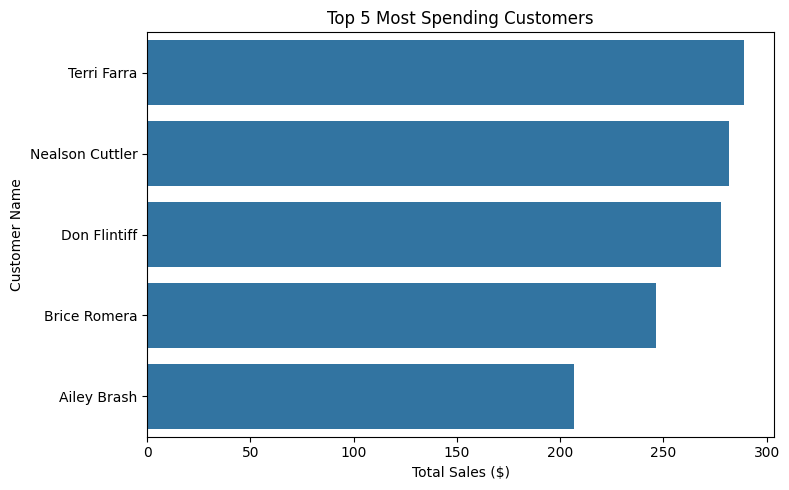

In [29]:
# Visualize Most Spending Customers
plt.figure(figsize=(8, 5))
sns.barplot(y=total_spend_per_customer.index, x=total_spend_per_customer.values)
plt.title('Top 5 Most Spending Customers')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.show()

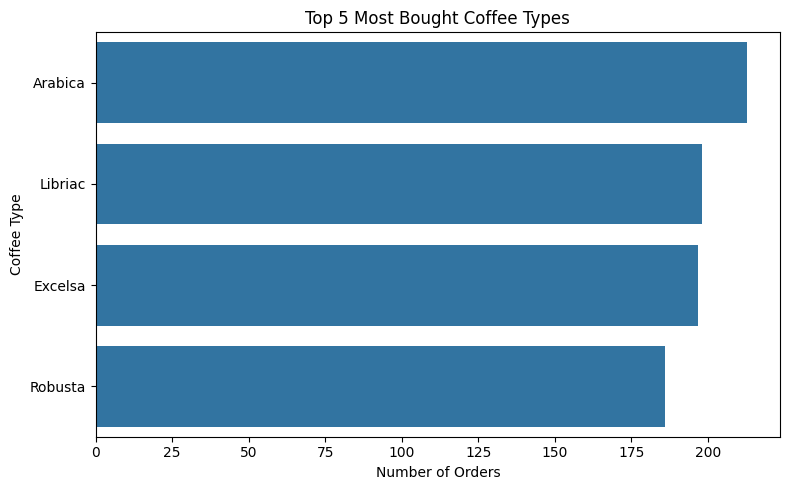

In [30]:
# Visualize Most Bought Coffee Types
plt.figure(figsize=(8, 5))
sns.barplot(y=most_bought_coffee_types.index, x=most_bought_coffee_types.values)
plt.title('Top 5 Most Bought Coffee Types')
plt.xlabel('Number of Orders')
plt.ylabel('Coffee Type')
plt.tight_layout()
plt.show()

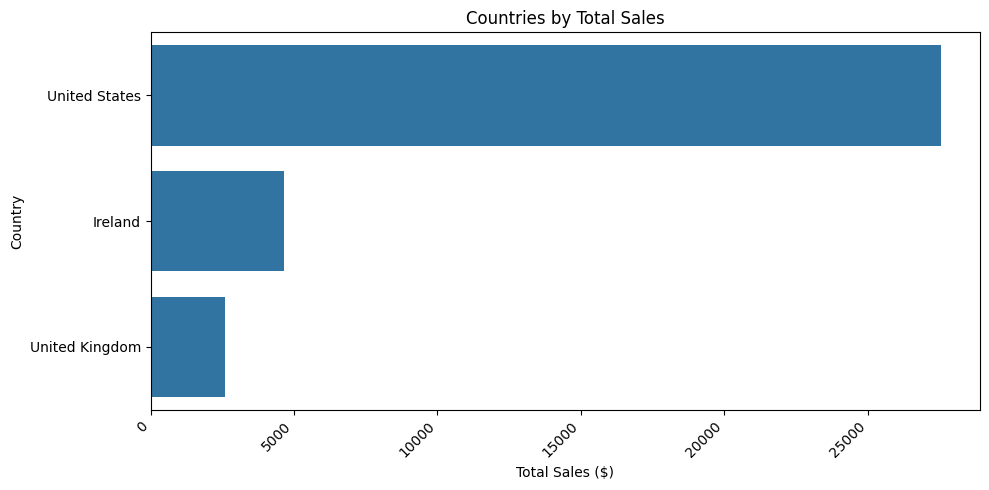

In [31]:
plt.figure(figsize=(10, 5))
sns.barplot(y=country_sales.index, x=country_sales.values)
plt.title('Countries by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()